In [3]:
print("all ok")

all ok


In [4]:
import sys, os

# Get project root — one level up from 'research_and_analyst'
print("Current working directory:", os.getcwd())
print("ABc",os.path.join(os.getcwd(), "../.."))
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
sys.path.append(project_root)

print("Project root added to path:", project_root)

Current working directory: /Users/madhushivagangaks/Desktop/Projects/automated-research-report-generation/research_and_analyst/notebook
ABc /Users/madhushivagangaks/Desktop/Projects/automated-research-report-generation/research_and_analyst/notebook/../..
Project root added to path: /Users/madhushivagangaks/Desktop/Projects/automated-research-report-generation


In [5]:
from research_and_analyst.utils.model_loader import ModelLoader

In [6]:
model_loader = ModelLoader()

{"timestamp": "2026-05-10T13:22:51.905418Z", "level": "info", "event": "Initializing ApiKeyManager"}
{"timestamp": "2026-05-10T13:22:51.905981Z", "level": "info", "event": "OPENAI_API_KEY loaded successfully from environment"}
{"timestamp": "2026-05-10T13:22:51.906469Z", "level": "info", "event": "GOOGLE_API_KEY loaded successfully from environment"}
{"timestamp": "2026-05-10T13:22:51.906778Z", "level": "info", "event": "GROQ_API_KEY loaded successfully from environment"}
{"path": "/Users/madhushivagangaks/Desktop/Projects/automated-research-report-generation/research_and_analyst/config/configuration.yaml", "keys": ["embedding_model", "retriever", "llm"], "timestamp": "2026-05-10T13:22:51.909669Z", "level": "info", "event": "Configuration loaded successfully"}
{"config_keys": ["embedding_model", "retriever", "llm"], "timestamp": "2026-05-10T13:22:51.910078Z", "level": "info", "event": "YAML configuration loaded successfully"}


In [7]:
llm=model_loader.load_llm()

{"provider": "groq", "model": "qwen/qwen3-32b", "timestamp": "2026-05-10T13:22:54.724136Z", "level": "info", "event": "Loading LLM"}
{"provider": "groq", "model": "qwen/qwen3-32b", "timestamp": "2026-05-10T13:22:54.800402Z", "level": "info", "event": "LLM loaded successfully"}


In [8]:
llm.invoke("Hi").content

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


'<think>\nOkay, the user said "Hi". That\'s pretty open-ended. I should respond in a friendly and welcoming way. Maybe ask how I can assist them. Keep it simple and let them know I\'m here to help with whatever they need. Make sure the tone is positive and approachable.\n</think>\n\nHello! How can I assist you today? 😊'

In [9]:
from typing import List
from typing_extensions import TypedDict
from pydantic import BaseModel, Field, ConfigDict
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import AIMessage,HumanMessage , SystemMessage
from langgraph.checkpoint.memory import MemorySaver

In [10]:
class Analyst(BaseModel):
    model_config = ConfigDict(extra="forbid")
    
    name: str = Field(description="Name of the analyst.")
    role: str = Field(description="Role of the analyst in the context of the topic.")
    affiliation: str = Field(description="Primary affiliation of the analyst.")
    description: str = Field(description="Description of the analyst focus, concerns, and motives.")
    
    @property
    def persona(self) -> str:
        return f"Name: {self.name}\nRole: {self.role}\nAffiliation: {self.affiliation}\nDescription: {self.description}\n"

In [12]:
analyst = Analyst(
    name="Madhushivaganga KS",
    role="genai eng",
    affiliation="AI Research LAB",
    description="I am genai developer as well as mentor",
    )    

In [13]:
print(analyst.persona)

Name: Madhushivaganga KS
Role: genai eng
Affiliation: AI Research LAB
Description: I am genai developer as well as mentor



In [14]:
class Perspectives(BaseModel):
    analysts: List[Analyst] = Field(description="Comprehensive list of analysts with their roles and affiliations.")

In [15]:
class GenerateAnalystsState(TypedDict):
    topic: str #research topic
    max_analysts: int # number of analyst
    human_analyst_feedback: str # Human feedback
    analysts: List[Analyst] # Analyst asking questions

In [16]:
analyst_instructions="""You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:

1. First, review the research topic:
{topic}
        
2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: 
        
{human_analyst_feedback}
    
3. Determine the most interesting themes based upon documents and / or feedback above.
                    
4. Pick the top {max_analysts} themes.

5. Assign one analyst to each theme."""

In [17]:
print([analyst_instructions.format(
        topic="education",
        max_analysts=4,
        human_analyst_feedback="please exaplain only on AI"
        
        )] + ["Generate the set of analysts."])

['You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:\n\n1. First, review the research topic:\neducation\n\n2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: \n\nplease exaplain only on AI\n\n3. Determine the most interesting themes based upon documents and / or feedback above.\n\n4. Pick the top 4 themes.\n\n5. Assign one analyst to each theme.', 'Generate the set of analysts.']


In [18]:
def create_analyst(state:GenerateAnalystsState):
    """
    it is creating my analyst
    
    """
    topic = state["topic"]
    max_analysts = state["max_analysts"]
    human_analyst_feedback = state.get("human_analyst_feedback","")
    
    structured_llm = llm.with_structured_output(Perspectives)
    
    system_messages = analyst_instructions.format(
        topic=topic,
        max_analysts=max_analysts,
        human_analyst_feedback=human_analyst_feedback
        
        )
    analysts = structured_llm.invoke([SystemMessage(content=system_messages)]+ [HumanMessage(content="Generate the set of analysts.")])
    
    # Write the list of analysis to state
    return {"analysts": analysts.analysts}

In [19]:
create_analyst(
    {'topic': 'health',
    'max_analysts': 2,
    'human_analyst_feedback': 'give the real info'}
    )

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


{'analysts': [Analyst(name='Dr. Aisha Patel', role='Public Health Policy Analyst', affiliation='World Health Organization (WHO)', description='Focuses on global health equity, pandemic preparedness, and policy frameworks for resource-limited regions. Prioritizes evidence-based interventions and cross-border collaboration.'),
  Analyst(name='James Carter', role='Health Technology Innovation Lead', affiliation='Stanford Medicine X', description='Specializes in AI-driven diagnostics, telehealth accessibility, and ethical use of patient data. Advocates for tech solutions that bridge healthcare disparities.')]}

In [20]:
def human_feedback(state):
    """ No-op node that should be interrupted on """
    pass

In [21]:
def should_continue(state):
    feedback = (state.get("human_analyst_feedback") or "").strip().lower()
    if feedback and feedback not in ["", "none", "skip", "done", "continue"]:
        return "create_analyst"
    return END

In [22]:
from IPython.display import Image, display

## First Workflow

In [24]:
builder = StateGraph(GenerateAnalystsState)

In [25]:
builder.add_node("create_analyst",create_analyst)
builder.add_node("human_feedback", human_feedback)

In [26]:
builder.add_edge(START,"create_analyst")
builder.add_edge("create_analyst", "human_feedback")
builder.add_conditional_edges("human_feedback",
                        should_continue,
                        ["create_analyst",
                        END])

In [27]:
memory = MemorySaver()

In [28]:
graph = builder.compile(interrupt_before= ["human_feedback"],checkpointer= memory)

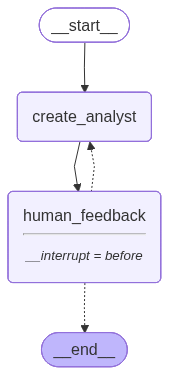

In [29]:
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [30]:
topic = "the benefits of adopting Langgraph as an agent framework"

In [31]:
max_analysts = 4
thread =  {"configurable":{"thread_id":1}}

In [32]:
for event in graph.stream({"topic":topic,"max_analysts":max_analysts},thread,stream_mode= "values"):
    analysts = event.get('analysts', '')
    
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


Name: Dr. Elena Martinez
Affiliation: AI Research Institute
Role: Technical Architect
Description: Focuses on Langgraph's technical innovations, emphasizing its ability to streamline complex agent workflows and improve task execution efficiency through modular design.
--------------------------------------------------
Name: James Carter
Affiliation: Open Source Community
Role: Developer Advocate
Description: Highlights Langgraph's ease of integration with existing tools and its developer-friendly APIs, reducing time-to-deployment for AI agent projects.
--------------------------------------------------
Name: Priya Nair
Affiliation: Tech Consulting Firm
Role: Enterprise Solutions Analyst
Description: Analyzes Langgraph's scalability and security features, critical for large-scale enterprise adoption in regulated industries.
--------------------------------------------------
Name: Michael Chen
Affiliation: Cloud Economics Lab
Role: Cost Optimization Specialist
Description: Examines Langg

In [33]:
state = graph.get_state(thread)

In [34]:
state.values

{'topic': 'the benefits of adopting Langgraph as an agent framework',
 'max_analysts': 4,
 'analysts': [Analyst(name='Dr. Elena Martinez', role='Technical Architect', affiliation='AI Research Institute', description="Focuses on Langgraph's technical innovations, emphasizing its ability to streamline complex agent workflows and improve task execution efficiency through modular design."),
  Analyst(name='James Carter', role='Developer Advocate', affiliation='Open Source Community', description="Highlights Langgraph's ease of integration with existing tools and its developer-friendly APIs, reducing time-to-deployment for AI agent projects."),
  Analyst(name='Priya Nair', role='Enterprise Solutions Analyst', affiliation='Tech Consulting Firm', description="Analyzes Langgraph's scalability and security features, critical for large-scale enterprise adoption in regulated industries."),
  Analyst(name='Michael Chen', role='Cost Optimization Specialist', affiliation='Cloud Economics Lab', descr

In [35]:
graph.update_state(thread,{"human_analyst_feedback":"add something from the startup perspective and focus on the latest enterprise application"},as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f14c737-f74d-6650-8002-8085641fafe9'}}

In [36]:
for event in graph.stream({"topic":topic,"max_analysts":max_analysts},thread,stream_mode= "values"):
    analysts = event.get('analysts', '')
    
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)

Name: Dr. Elena Martinez
Affiliation: AI Research Institute
Role: Technical Architect
Description: Focuses on Langgraph's technical innovations, emphasizing its ability to streamline complex agent workflows and improve task execution efficiency through modular design.
--------------------------------------------------
Name: James Carter
Affiliation: Open Source Community
Role: Developer Advocate
Description: Highlights Langgraph's ease of integration with existing tools and its developer-friendly APIs, reducing time-to-deployment for AI agent projects.
--------------------------------------------------
Name: Priya Nair
Affiliation: Tech Consulting Firm
Role: Enterprise Solutions Analyst
Description: Analyzes Langgraph's scalability and security features, critical for large-scale enterprise adoption in regulated industries.
--------------------------------------------------
Name: Michael Chen
Affiliation: Cloud Economics Lab
Role: Cost Optimization Specialist
Description: Examines Langg

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


Name: Alex Carter
Affiliation: LangChain Innovations
Role: Startup Technology Evangelist
Description: Focuses on how Langgraph enables startups to rapidly prototype and deploy AI agents with minimal infrastructure overhead, emphasizing cost-effectiveness and agility in competitive markets.
--------------------------------------------------
Name: Jamie Chen
Affiliation: GlobalTech Consulting
Role: Enterprise Solutions Architect
Description: Analyzes Langgraph's role in scaling enterprise-grade AI applications, highlighting its integration with cloud-native architectures and compliance with security standards for large organizations.
--------------------------------------------------
Name: Samira Patel
Affiliation: TechBridge Labs
Role: AI Integration Specialist
Description: Examines Langgraph's compatibility with existing enterprise systems, focusing on seamless API integration and its ability to enhance legacy workflows with modern agent-based automation.
------------------------------

In [37]:
state = graph.get_state(thread)

In [38]:
state.values

{'topic': 'the benefits of adopting Langgraph as an agent framework',
 'max_analysts': 4,
 'human_analyst_feedback': 'add something from the startup perspective and focus on the latest enterprise application',
 'analysts': [Analyst(name='Alex Carter', role='Startup Technology Evangelist', affiliation='LangChain Innovations', description='Focuses on how Langgraph enables startups to rapidly prototype and deploy AI agents with minimal infrastructure overhead, emphasizing cost-effectiveness and agility in competitive markets.'),
  Analyst(name='Jamie Chen', role='Enterprise Solutions Architect', affiliation='GlobalTech Consulting', description="Analyzes Langgraph's role in scaling enterprise-grade AI applications, highlighting its integration with cloud-native architectures and compliance with security standards for large organizations."),
  Analyst(name='Samira Patel', role='AI Integration Specialist', affiliation='TechBridge Labs', description="Examines Langgraph's compatibility with ex

In [39]:
memory.storage.items()

dict_items([('1', defaultdict(<class 'dict'>, {'': {'1f14c737-a371-6cf2-bfff-bae3b7a75127': (('msgpack', b'\x86\xa1v\x04\xa2ts\xd9 2026-05-10T13:23:48.057821+00:00\xa2id\xd9$1f14c737-a371-6cf2-bfff-bae3b7a75127\xb0channel_versions\x81\xa9__start__\xd9300000000000000000000000000000001.0.5869006445105911\xadversions_seen\x81\xa9__input__\x80\xb0updated_channels\x91\xa9__start__'), ('msgpack', b'\x83\xa6source\xa5input\xa4step\xff\xa7parents\x80'), None), '1f14c737-a377-6350-8000-74861d581f11': (('msgpack', b'\x86\xa1v\x04\xa2ts\xd9 2026-05-10T13:23:48.060032+00:00\xa2id\xd9$1f14c737-a377-6350-8000-74861d581f11\xb0channel_versions\x84\xa9__start__\xd9400000000000000000000000000000002.0.21481825581955394\xa5topic\xd9400000000000000000000000000000002.0.21481825581955394\xacmax_analysts\xd9400000000000000000000000000000002.0.21481825581955394\xb8branch:to:create_analyst\xd9400000000000000000000000000000002.0.21481825581955394\xadversions_seen\x82\xa9__input__\x80\xa9__start__\x81\xa9__start_